In [1]:
from pathlib import Path
import numpy as np
import cv2

data_path = Path("/Volumes/Pluggable_1TB/thermal_images/archive/").expanduser()


thermal_paths = list(data_path.glob("set*/V*/lwir"))

In [2]:

all_files = []

for lwir_dir in thermal_paths:
    if lwir_dir.is_dir():
        files = list(lwir_dir.iterdir()) 
        all_files.extend(files)

print (len(all_files))

47264


In [7]:
f = open ("/Volumes/Pluggable_1TB/thermal_images/archive/set00/V000/lwir/I00000.jpg","rb")

In [6]:
from scipy import ndimage

def roberts_cross(img_path):
    # Read the image using OpenCV
    #Reads the image from the specified path in grayscale, simplifying processing.
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    # Define the Roberts Cross kernels for horizontal and vertical edge detection.
    gx = np.array([[1, 0], [0, -1]])
    gy = np.array([[0, 1], [-1, 0]])
    
    # Apply convolution operations to calculate horizontal and vertical gradients.
    gradient_x = ndimage.convolve(image, gx)
    gradient_y = ndimage.convolve(image, gy)
    
    # Compute the magnitude of the gradient using the square root of the sum of squares.
    magnitude = np.sqrt(gradient_x**2 + gradient_y**2)
    
    # Apply a threshold to create a binary mask, where pixels with magnitudes exceeding the threshold are considered part of an edge.
    threshold = 10
    edges = magnitude > threshold
    
    return edges

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def sobel_edge_detector(image_path, flag=True):
    # Read the image using OpenCV
    if flag:
        image = cv2.imread(image_path, 0)
    else:
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply Sobel operator
    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    # Calculate gradient magnitude
    magnitude = np.sqrt(sobel_x**2 + sobel_y**2)

    # Apply a threshold to identify edges
    threshold = 40
    edges = magnitude > threshold

    edges_img = (edges.astype(np.uint8) * 255)

    return edges_img


In [8]:
def display_image (original_image_thermal, edge_image, robert):
    # Plotting the images using matplotlib
    plt.figure(figsize=(10, 5))
    
    # Original Image
    plt.subplot(1, 3, 1)
    plt.imshow(original_image_thermal)
    plt.title('Original Image')
    plt.axis('off')
    
    # Edge-detected Image
    plt.subplot(1, 3, 2)
    plt.imshow(edge_image, cmap='gray')
    plt.title('Edge-detected Image (Sobel)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(robert, cmap='gray')
    plt.title('Edge-detected Image (Robert)')
    plt.axis('off')
    
    # Display the images
    plt.show()

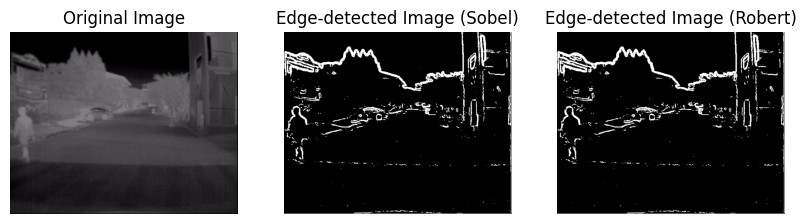

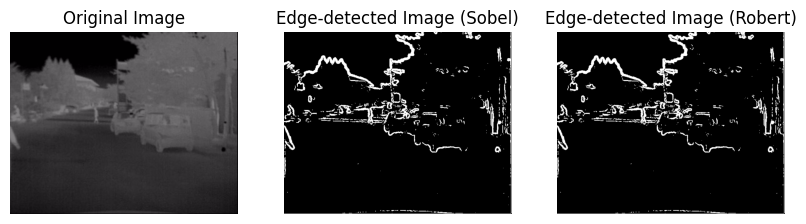

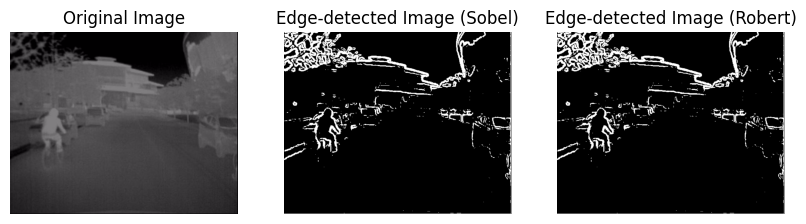

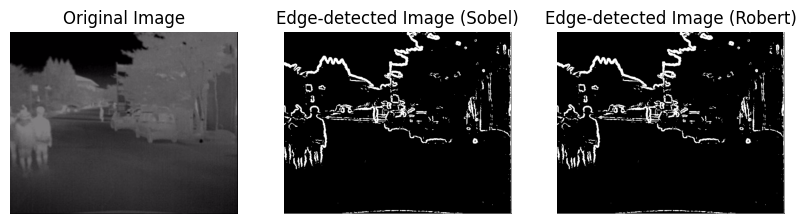

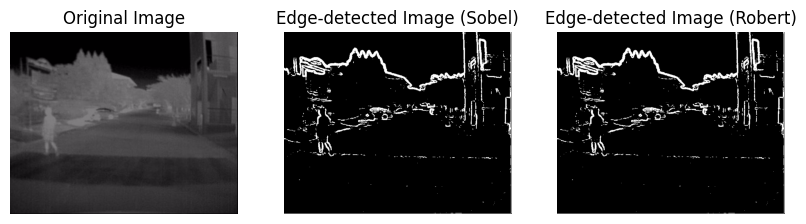

In [47]:
for i in range (0,5):
    sobel_image = sobel_edge_detector(all_files[i])
    robert_image = sobel_edge_detector(all_files[i], False)
    #robert_image = roberts_cross(all_files[i])
    original_image = cv2.imread(all_files[i])
    display_image(original_image, sobel_image, robert_image)


In [54]:
image = cv2.imread(all_files[0], cv2.IMREAD_GRAYSCALE)
cv2.imshow('greyscale', image)

og_image = cv2.imread(all_files[0], 0)
cv2.imshow('image', og_image)

cv2.waitKey(0)  
cv2.destroyAllWindows()


In [ ]:
!pip install accelerate

In [ ]:
from diffusers import (
    StableDiffusionControlNetPipeline,
    ControlNetModel,
    UniPCMultistepScheduler,
)
from diffusers.utils import load_image
from PIL import Image
import torch
import numpy as np
import cv2

print ('import')

# --------- YOUR SOBEL EDGE DETECTOR ----------
def sobel_edge_detector(image_path, flag=True):
    image_path = str(image_path)
    if flag:
        image = cv2.imread(image_path, 0)
    else:
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

    magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    threshold = 40
    edges = (magnitude > threshold).astype(np.uint8) * 255
    return edges


edges_img = sobel_edge_detector(all_files[0])


# Must save BEFORE loading into ControlNet
Image.fromarray(edges_img).save("sobel_edges.png")
edge_image = load_image("sobel_edges.png")

print ('load image')

# Load Control Net
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny", 
    torch_dtype=torch.float16
)

print ('load controlnet')


pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5", 
    controlnet=controlnet, 
    torch_dtype=torch.float16
)

print ('pipe')


pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)


pipe.enable_model_cpu_offload()


# --------- INFERENCE ----------
prompt = "realistic photograph"

out = pipe(
    prompt=prompt,
    image=edge_image,
    num_inference_steps=20,   # reduced for speed
)

# --------- SAVE RESULT ----------
out.images[0].save("reconstructed.png")
print("✅ Saved → reconstructed.png")